In [21]:
from cmath import tau
import pandas as pd
import json
from pathlib import Path

log_dir = Path("../experiments/32 adaptive")

all_data = []
for file_path in log_dir.glob("*.json"):
    with open(file_path, 'r', encoding='utf-8') as f:
        all_data.append(json.load(f))

df = pd.json_normalize(all_data)

if 'timestamp' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

print(f"Successfully read {len(df)} experiment runs.")

df['problem_type'] = df['problem.dotmark_type']



restart_col = 'solver.restart_check'
runtime_col = 'metrics.runtime_seconds'
iter_col    = 'metrics.iterations'

print(f"Not completed: {len(df[df['metrics.status'] != 'completed'])}")


Successfully read 185 experiment runs.
Not completed: 3


C:\Users\Felix\AppData\Local\Temp\ipykernel_7924\690492556.py:12: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  runtime_graph = sns.catplot(


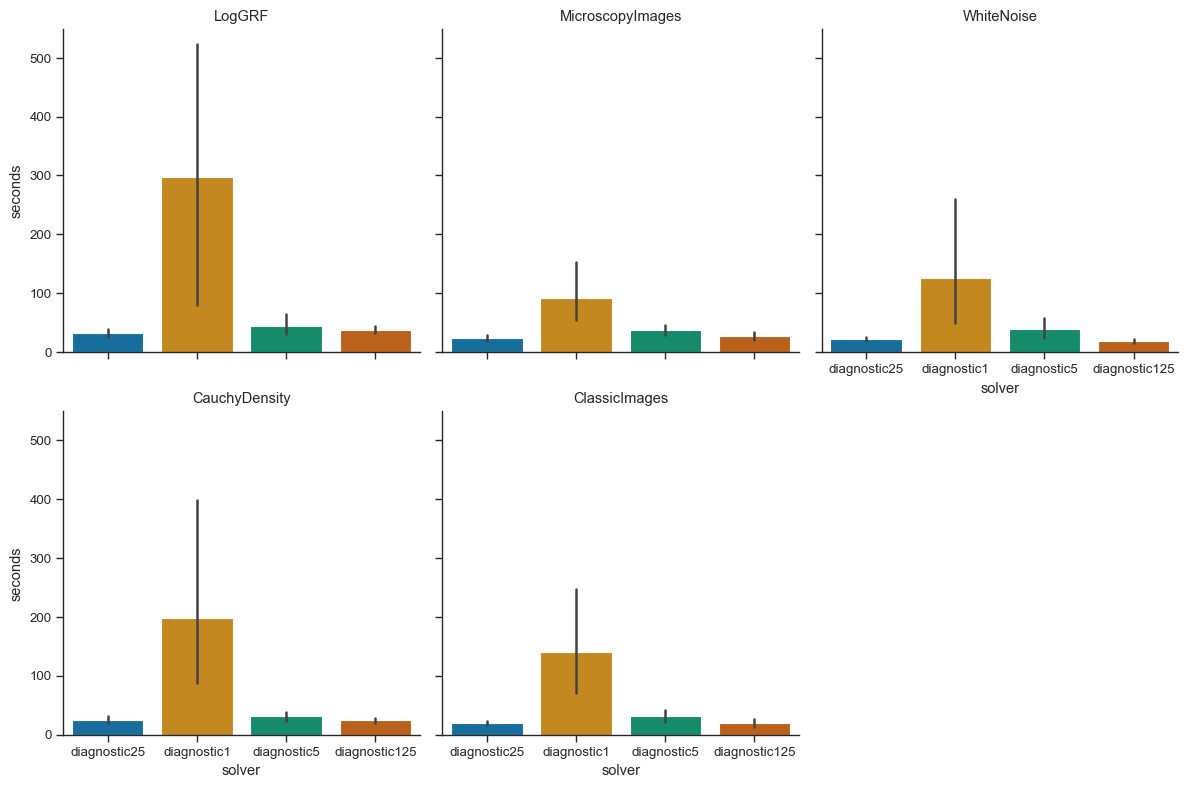

In [22]:
import seaborn as sns
import matplotlib as mpl

mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman'] + mpl.rcParams['font.serif']
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['savefig.facecolor'] = 'white'
sns.set_theme(style='ticks', context='paper', font_scale=1.1)
palette = sns.color_palette("colorblind")

runtime_graph = sns.catplot(
    data=df,
    y='metrics.runtime_seconds',
    x='solver.name',
    hue='solver.name',  # Farbe pro Solver
    kind='bar',
    col='problem_type',
    col_wrap=3,
    palette=palette,
    height=4,
    aspect=1.0,
    legend=False,
    sharey=True
)

runtime_graph.set(xlabel='solver', ylabel='seconds')
runtime_graph.set_titles(template="{col_name}")

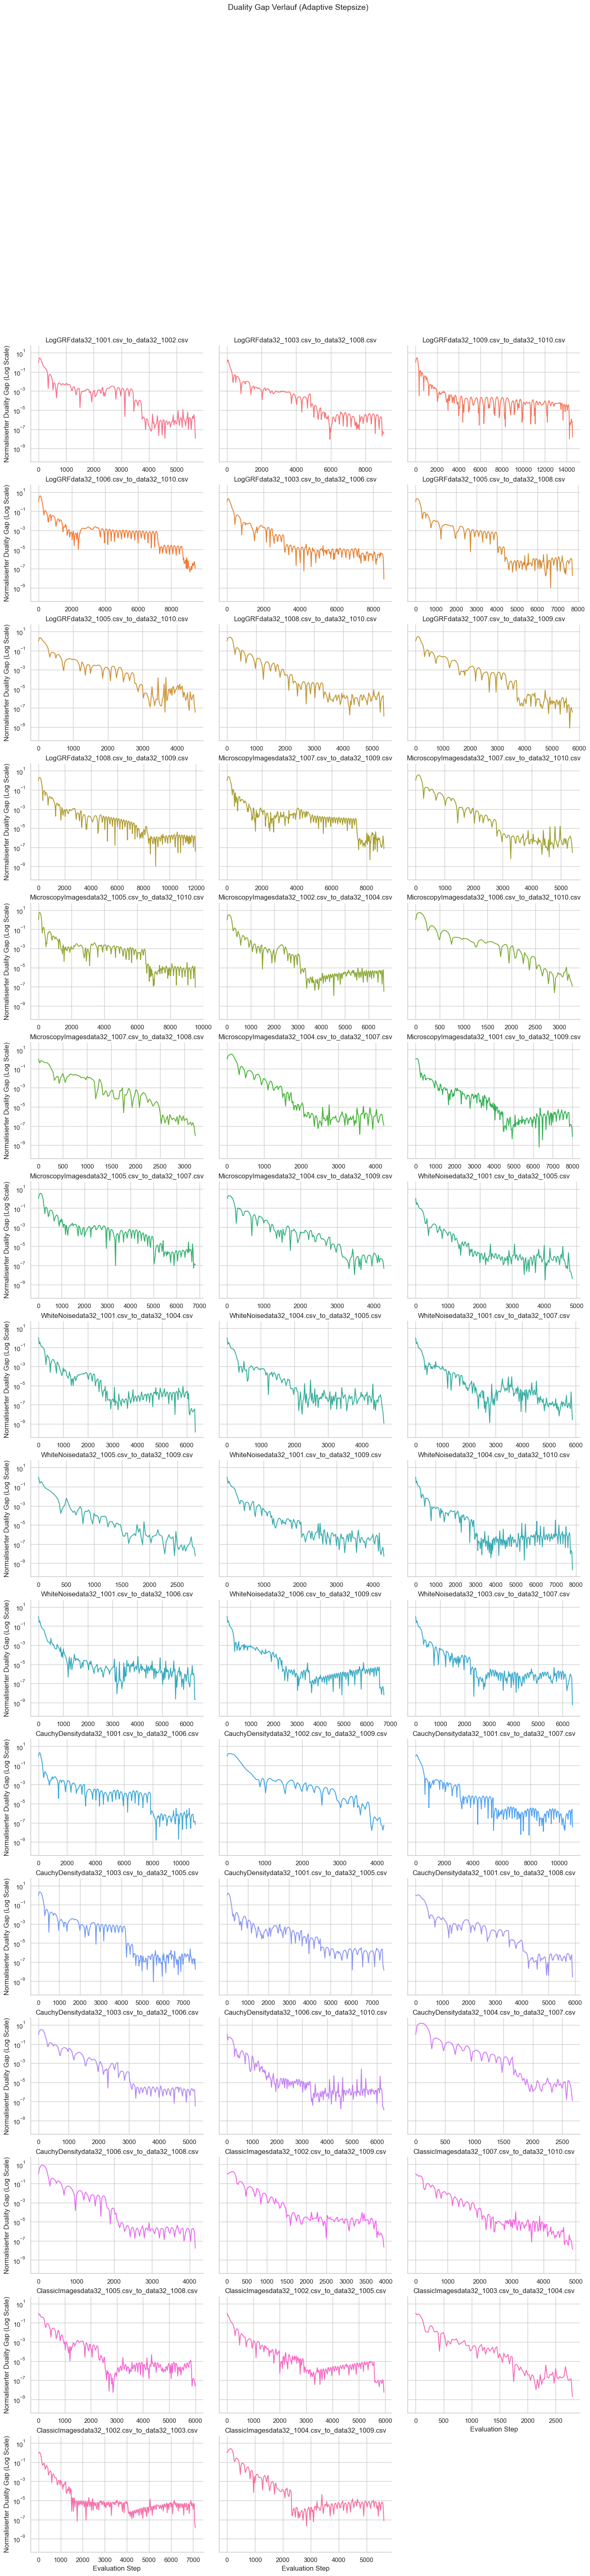

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

source_df = df

df_filtered = source_df[source_df['solver.name'] == 'diagnostic25'].copy()

records = []
for idx, row in df_filtered.iterrows():
    gaps = row.get('sequences.duality_gap', [])

    diag_i = int(row.get('solver.diagnostik_i', 1))

    if not isinstance(gaps, list) or len(gaps) == 0:
        continue

    initial_gap = gaps[0]
    if initial_gap == 0 or pd.isna(initial_gap):
        continue

    for i, gap in enumerate(gaps):
        records.append({
            'run_id': idx,
            'step': i * diag_i,
            'normalized_gap': gap / initial_gap,
            'problem_type': row.get('problem.name', 'unknown')
        })

if not records:
    print("Keine Daten gefunden! Prüfe die Filternamen und Spaltenbezeichnungen.")
else:
    df_long = pd.DataFrame(records)

    sns.set_theme(style="whitegrid")

    g = sns.relplot(
        data=df_long,
        x='step',
        y='normalized_gap',
        col='problem_type',
        hue='problem_type',
        kind='line',
        estimator='mean',
        errorbar='ci',
        col_wrap=3,
        height=4,
        aspect=1.2,
        facet_kws={'sharex': False},
        legend=False
    )

    g.set(yscale='log')
    g.set_titles("{col_name}")
    g.set_axis_labels("Evaluation Step", "Normalisierter Duality Gap (Log Scale)")
    g.fig.suptitle('Duality Gap Verlauf (Adaptive Stepsize)', fontsize=14)
    g.fig.subplots_adjust(top=0.85)

    plt.show()

In [26]:
runtime_graph.savefig('transportation_runtime_results.png', dpi=300, bbox_inches='tight')
runtime_graph.savefig('transportation_runtime_results.pdf', bbox_inches='tight')

In [32]:
g.savefig('transportation_gap3.png', dpi=300, bbox_inches='tight')
#duality_gap_graph.savefig('transportation_gap_results.pdf', bbox_inches='tight')